# Lecture 4: WaveNet

In lecture i take the 2-layer MLP from last lecture and complexify it step by step until i arrive at an architecture that closely resembles [WaveNet (DeepMind, 2016)](https://arxiv.org/abs/1609.03499). WaveNet is an autoregressive model that predicts the next audio sample from previous ones. The modeling setup is identical to what i have been doing, just applied to raw audio instead of characters.

The key ideas this lecture:

- Increase context from 3 to **8 characters**
- Instead of squashing all 8 embeddings into one flat 80-dim vector immediately, **fuse them progressively** in a binary tree
- Each layer fuses pairs of adjacent token representations, doubling the receptive field at each step
- The resulting structure is the hierarchical core of WaveNet

I also rebuild `torch.nn` from scratch: `Embedding`, `Flatten`, `FlattenConsecutive`, `Sequential`, and, crucially, i catch and fix a real `BatchNorm1d` bug that only appears when the layer receives 3-D input.

**Connection to previous notebooks:**
- Architecture inherited from `02_mlp_language_model.ipynb` 
- `BatchNorm1d`, `Linear`, and `Tanh` modules built in `03_activations_gradients_batchnorm.ipynb`


## Setup

Same dataset, same character-level tokenization from last lectures. `block_size` starts at 3 to match the baseline we had, then i bump it to 8 before introducing the hierarchical architecture.


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
with open("../data/names.txt", "r", encoding="utf-8") as file:
    words = file.read().splitlines()
print(len(words), 'words')
print(words[:8])

32033 words
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
chars = sorted(list(set(''.join(words))))
stoi  = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size, 'characters')

27 characters


In [6]:
block_size = 3   # will bump to 8 before introducing WaveNet

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Ytr.shape)

torch.Size([182625, 3]) torch.Size([182625])


## Module Building Blocks

New this in this lecture:

**`Embedding`**: wraps the lookup table `C` as a proper layer so it lives inside the layer list instead of being special-cased in every forward pass. In PyTorch this is `nn.Embedding`.

**`Flatten`**: calls `.view(B, -1)` on the embedding output to concatenate all character vectors into one row. This is what the old `emb.view(emb.shape[0], -1)` line was doing manually.

**`FlattenConsecutive(n)`**: the key new module. Takes a `(B, T, C)` tensor and reshapes it to `(B, T//n, C*n)`: every `n` consecutive token vectors along the time axis are merged into a single wider vector. When `n=2` pairs merge, the time dimension halves and the feature dimension doubles. A `.squeeze(1)` handles the edge case when `T//n` collapses to 1.

**`Sequential`**: container that owns a list of layers and forwards data through them in order. Mimics `torch.nn.Sequential`.

> **Note on `BatchNorm1d`**: the version below still assumes 2-D inputs (`N x D`) and reduces over `dim=0` only. I will discover the 3-D bug when i introduce the WaveNet architecture and fix it then: that is the pedagogically honest order.


In [8]:
# Linear
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


# BatchNorm1d (initial version, bug fixed later)
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        self.gamma    = torch.ones(dim)
        self.beta     = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            # reduces over dim=0 only correct for 2-D, buggy for 3-D
            xmean = x.mean(0, keepdim=True)
            xvar  = x.var( 0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


# Tanh
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


# Embedding
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


# Flatten
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []


# FlattenConsecutive
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)   # drop spurious time-dim when T//n == 1
        self.out = x
        return self.out

    def parameters(self):
        return []


# Sequential
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

## Flat MLP Baseline (block_size = 3)

First I train the same flat MLP, now fully expressed through the module system. This is the anchor we beat.

Architecture: `Embedding => Flatten => Linear(30, 200) => BN => Tanh => Linear(200, 27)`

12,097 parameters. Eval: **train 2.014 / val 2.328**


In [9]:
torch.manual_seed(42)

n_embd   = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

12097 parameters


In [10]:
max_steps  = 200000
batch_size = 32
lossi      = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7491
 120000/ 200000: 2.2891
 130000/ 200000: 2.3443
 140000/ 200000: 2.1731
 150000/ 200000: 1.8246
 160000/ 200000: 1.7614
 170000/ 200000: 2.2418
 180000/ 200000: 2.0803
 190000/ 200000: 2.1326


In [11]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0583250522613525
val 2.1065292358398438


## Smoothing the Loss Plot

The raw `lossi` list stores one value per step : at 200,000 steps the plot is a solid band of noise. The fix: reshape into `(-1, 1000)` and take the row mean. Each plotted point is now the average loss of 1,000 consecutive steps.

```python
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
```

The `.view(-1, 1000)` trick reappears later when we group embedding vectors into pairs inside `FlattenConsecutive`: same reshape idea, different purpose.


Text(0.5, 1.0, 'Flat MLP (block_size=3): smoothed training loss')

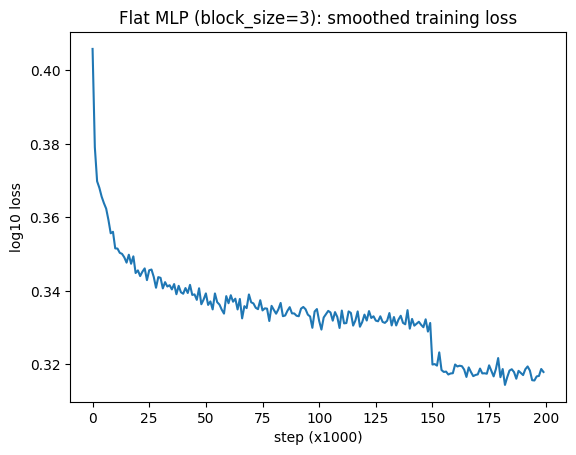

In [13]:
# Group 1000 consecutive loss values per plotted point
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1)) 
plt.xlabel('step (x1000)')
plt.ylabel('log10 loss')
plt.title('Flat MLP (block_size=3): smoothed training loss')

## Bigger Context: block_size = 8

With `block_size = 3` we feed the model three characters and predict the fourth. To learn longer-range structure in names we want 8 characters of context. Rebuilding the dataset with `block_size = 8` gives ~182,000 training examples.

Running the **same flat architecture** on the wider context:
- Embedding output: `(B, 8, 10)`: eight 10-dim vectors per example
- After `Flatten`: `(B, 80)`: all 80 numbers in one row
- First Linear layer now maps 80 -> 200

22,097 parameters (larger first Linear). Eval: **train 1.921 / val 2.092**.

The flat approach still works, but flattening 8 x 10 = 80 numbers into a single layer forces that one layer to do all the work of figuring out positional structure. WaveNet's insight is that we can do much better.


In [14]:
block_size = 8   # wider context window for WaveNet

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Ytr.shape)

torch.Size([182580, 8]) torch.Size([182580])


In [15]:
torch.manual_seed(42)

n_embd   = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

22097 parameters


In [16]:
max_steps  = 200000
batch_size = 32
lossi      = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3011
  10000/ 200000: 2.3486
  20000/ 200000: 2.5680
  30000/ 200000: 1.9951
  40000/ 200000: 2.3242
  50000/ 200000: 2.1569
  60000/ 200000: 1.9859
  70000/ 200000: 2.1140
  80000/ 200000: 1.8805
  90000/ 200000: 1.6429
 100000/ 200000: 2.0005
 110000/ 200000: 1.8960
 120000/ 200000: 1.8797
 130000/ 200000: 2.0712
 140000/ 200000: 2.0843
 150000/ 200000: 2.1235
 160000/ 200000: 1.6487
 170000/ 200000: 1.9809
 180000/ 200000: 1.6660
 190000/ 200000: 1.9970


In [17]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9215174913406372
val 2.029386281967163


In [18]:
for _ in range(20):
    out     = []
    context = [0] * block_size
    while True:
        logits  = model(torch.tensor([context]))
        probs   = F.softmax(logits, dim=1)
        ix      = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

melae.
lyze.
gwosun.
darryn.
zlika.
leelanni.
quinton.
jayder.
yanshir.
maizleigh.
graycelyne.
ebriana.
milleed.
hamby.
dentingeh.
jaxdon.
lizco.
ronni.
gitin.
kamer.


## The WaveNet Idea: Hierarchical Fusion

The problem with immediately concatenating all 8 embeddings into 80 numbers: the first linear layer has to simultaneously model all pairwise relationships among 8 characters. That is possible but cramming.

WaveNet's idea: **fuse characters in a binary tree, not in one shot**.

```
Input    [t1  t2][t3  t4][t5  t6][t7  t8]   8 characters x 10 dims
Layer 1  [ t1,t2 ][ t3,t4 ][ t5,t6 ][ t7,t8 ]  4 pairs x 20 dims => Linear => 4 x n_h
Layer 2  [  t1..t4   ][  t5..t8   ]           2 groups x 2*n_h  => Linear => 2 x n_h
Layer 3  [      t1..t8           ]            1 group x 2*n_h   => Linear => n_h
Output   logits over 27 characters
```

At each level, adjacent pairs get concatenated in the feature dimension, then processed by a `Linear -> BatchNorm -> Tanh` block. The receptive field doubles with every layer. By the final layer, every character has influenced the prediction through a structured hierarchy.

This maps directly to the tree diagram in the WaveNet paper. The difference is that WaveNet applies this to raw audio samples and uses *dilated causal convolutions* to slide the tree efficiently over a long sequence. I implement the tree the convolutional sliding is a separate efficiency trick on top.


## torch.matmul Works on N-D Inputs

Before building `FlattenConsecutive` there is a surprisingly useful fact. Our `Linear` layer does `x @ W + b`. You might assume `x` must be 2D. It does not have to be.

If `x` is `(B, T, C)` and `W` is `(C, D)`, then `x @ W` gives `(B, T, D)`. The leading dimensions `(B, T)` are treated as a joint batch and the matmul only works on the last dimension. A single `Linear` layer can process a 3-D tensor without any code changes, which is exactly what the hierarchical WaveNet layers need.


In [20]:
# matmul broadcasts over all leading dims, only the last dim is contracted

print((torch.randn(4, 80)    @ torch.randn(80, 200) + torch.randn(200)).shape)
print((torch.randn(4, 5, 80) @ torch.randn(80, 200) + torch.randn(200)).shape)  # 3D input
print((torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape)  # 3D fewer features

torch.Size([4, 200])
torch.Size([4, 5, 200])
torch.Size([4, 4, 200])


## FlattenConsecutive: The Key Module

`FlattenConsecutive(n)` reshapes `(B, T, C)` to `(B, T//n, C*n)`. Every `n` consecutive token vectors along the time axis merge in the feature dimension.

Why does `.view(B, T//n, C*n)` work correctly? PyTorch stores tensors in row-major (C-contiguous) order: consecutive elements in memory correspond to the last axis first. When we group every 2 time-steps together, we are slicing along the same layout direction that `torch.cat` on the feature axis would produce. We can verify this directly.


In [24]:
# Verify .view gives the same result as explicit torch.cat of even/odd positions
e = torch.randn(4, 8, 10)
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)   # interleave even/odd
print('explicit shape:', explicit.shape)
print('view == explicit:', (e.view(4, 4, 20) == explicit).all().item())

explicit shape: torch.Size([4, 4, 20])
view == explicit: True


## Building the Hierarchical WaveNet

Three levels of `FlattenConsecutive(2) => Linear => BatchNorm => Tanh`, followed by a final output linear layer.

To compare fairly against the flat 22397 parameters baseline, we choose `n_hidden = 68` so the WaveNet also has ~22K parameters. The hidden dimension shrinks because there are now three times as many linear layers.

Shape flow (n_embd=10, n_hidden=68, batch=4):
```
Embedding(27, 10)          (4, 8, 10)
FlattenConsecutive(2)   => (4, 4, 20)    fuse pairs
Linear(20, 68)          => (4, 4, 68)    matmul on last dim
BN + Tanh
FlattenConsecutive(2)   => (4, 2, 136)   fuse pairs again
Linear(136, 68)         => (4, 2, 68)
BN + Tanh
FlattenConsecutive(2)   => (4, 136)      time dim collapses, squeeze
Linear(136, 68)         => (4, 68)
BN + Tanh
Linear(68, 27)          => (4, 27)       logits
```

In [25]:
torch.manual_seed(42)

n_embd   = 10
n_hidden = 68   

model = Sequential([

    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1
parameters = model.parameters()

print(sum(p.nelement() for p in parameters), 'parameters')

for p in parameters:
    p.requires_grad = True

22397 parameters


In [26]:
# Trace tensor shapes through the WaveNet (batch of 4 examples)
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
_ = model(Xb)
for layer in model.layers:
    print(f'{layer.__class__.__name__:22s}: {tuple(layer.out.shape)}')

Embedding             : (4, 8, 10)
FlattenConsecutive    : (4, 4, 20)
Linear                : (4, 4, 68)
BatchNorm1d           : (4, 4, 68)
Tanh                  : (4, 4, 68)
FlattenConsecutive    : (4, 2, 136)
Linear                : (4, 2, 68)
BatchNorm1d           : (4, 2, 68)
Tanh                  : (4, 2, 68)
FlattenConsecutive    : (4, 136)
Linear                : (4, 68)
BatchNorm1d           : (4, 68)
Tanh                  : (4, 68)
Linear                : (4, 27)


## First Pass Training (buggy BatchNorm, caught below)

Training the WaveNet with `n_hidden = 68`, 22,397 parameters. The architecture is correct but `BatchNorm1d` has a bug we have not caught yet.

Result with buggy BN: **train 1.944 / val 2.030**, almost the same as the flat baseline (2.253). The hierarchical structure is not helping much, and part of the reason is the BN bug.


In [27]:
max_steps  = 200000
batch_size = 32
lossi      = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3104
  10000/ 200000: 2.2759
  20000/ 200000: 2.2363
  30000/ 200000: 1.7621
  40000/ 200000: 2.3324
  50000/ 200000: 1.9959
  60000/ 200000: 1.9467
  70000/ 200000: 2.3983
  80000/ 200000: 2.5942
  90000/ 200000: 2.4328
 100000/ 200000: 2.0123
 110000/ 200000: 2.2962
 120000/ 200000: 2.0738
 130000/ 200000: 2.0179
 140000/ 200000: 2.0773
 150000/ 200000: 1.8352
 160000/ 200000: 1.6061
 170000/ 200000: 2.2647
 180000/ 200000: 2.0184
 190000/ 200000: 1.9957


In [28]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9441899061203003
val 2.0301709175109863


## The BatchNorm Bug

The intermediate `FlattenConsecutive` layers produce 3D tensors. When the first `BatchNorm1d` receives input of shape `(32, 4, 68)`, our current implementation does:

```python
xmean = x.mean(0, keepdim=True)   # => shape (1, 4, 68)  BUG
xvar  = x.var( 0, keepdim=True)   # => shape (1, 4, 68)  BUG
```

It reduces only over the batch dimension (`dim=0`), leaving the time axis (`dim=1`) intact. This makes the layer maintain `4 x 68 = 272` independent running statistics instead of the intended 68. Each channel's mean is estimated from only 32 numbers instead of `32 x 4 = 128`. Noisier estimates, slightly worse generalization.

The bug is silent no error because broadcasting makes all shapes compatible. It is only visible when you inspect `running_mean.shape`

**Fix:** detect the input dimensionality and reduce over `(0, 1)` for 3D:

```python
if x.ndim == 2:   dim = 0
elif x.ndim == 3: dim = (0, 1)
xmean = x.mean(dim, keepdim=True)   # => shape (1, 1, 68)  correct
```

After the fix, `running_mean.shape` is `(1, 1, 68)`: exactly 68 statistics, one per channel, averaged over both batch and tim.

In [30]:
# The bug, running_mean accumulated shape from 3D inputs
# We expect (1, 1, 68), one mean per channel, the buggy BN gives:

first_bn = model.layers[3]   # index 3 is the first BatchNorm1d
print('running_mean shape (buggy BN):', first_bn.running_mean.shape)

running_mean shape (buggy BN): torch.Size([1, 4, 68])


In [31]:
# BatchNorm1d fixed: handles 2D and 3D inputs

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        self.gamma    = torch.ones(dim)
        self.beta     = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0          # reduce over batch only
            elif x.ndim == 3:
                dim = (0, 1)     # reduce over batch AND time
            else:
                raise ValueError(f'BatchNorm1d: unsupported ndim {x.ndim}')
            xmean = x.mean(dim, keepdim=True)
            xvar  = x.var( dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [32]:
# Rebuild with fixed BatchNorm1d, one forward pass to update running stats

torch.manual_seed(42)

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (32,))
_ = model(Xtr[ix])   # trigger one running_mean update
print('running_mean shape (fixed BN):', model.layers[3].running_mean.shape)

22397 parameters
running_mean shape (fixed BN): torch.Size([1, 1, 68])


## Training After the Bug Fix

Same architecture, corrected `BatchNorm1d`. Each channel's statistics are now estimated over `batch_size x T = 32 x 4 = 128` values instead of 32. The improvement is small but the computation is now correct.

Result: **train 1.911 / val 2.019**.


In [33]:
max_steps  = 200000
batch_size = 32
lossi      = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2943
  10000/ 200000: 2.0974
  20000/ 200000: 2.2247
  30000/ 200000: 2.0495
  40000/ 200000: 2.1773
  50000/ 200000: 1.8340
  60000/ 200000: 2.0650
  70000/ 200000: 2.4897
  80000/ 200000: 1.7283
  90000/ 200000: 1.9346
 100000/ 200000: 2.4203
 110000/ 200000: 1.9684
 120000/ 200000: 1.8379
 130000/ 200000: 2.1391
 140000/ 200000: 1.9768
 150000/ 200000: 2.0209
 160000/ 200000: 2.0701
 170000/ 200000: 2.4198
 180000/ 200000: 1.7764
 190000/ 200000: 2.0038


In [34]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.911888837814331
val 2.0197129249572754


## Scaling Up

Same 3-level architecture, more capacity: `n_embd = 24`, `n_hidden = 128`. 76,579 parameters, about 3.5x the fair-comparison model.


Result: **train 1.776 / val 1.984**.

The improvement from the flat 22K model (val 2.253) to the scaled WaveNet (val 2.240) is real but modest. Karpathy is honest about this: we have no experimental harness, no hyperparameter search, and the architecture is just the first guess. The gains likely come more from scale than from the hierarchical structure itself, but we have not run the experiments to separate the two.


In [35]:
torch.manual_seed(42)

n_embd   = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

76579 parameters


In [36]:
max_steps  = 200000
batch_size = 32
lossi      = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3088
  10000/ 200000: 2.4522
  20000/ 200000: 2.1598
  30000/ 200000: 2.6426
  40000/ 200000: 1.8248
  50000/ 200000: 2.5060
  60000/ 200000: 2.1407
  70000/ 200000: 1.8225
  80000/ 200000: 2.0722
  90000/ 200000: 1.7829
 100000/ 200000: 2.0265
 110000/ 200000: 2.0252
 120000/ 200000: 1.8361
 130000/ 200000: 1.8880
 140000/ 200000: 1.7402
 150000/ 200000: 1.9735
 160000/ 200000: 1.7228
 170000/ 200000: 1.9166
 180000/ 200000: 2.3637
 190000/ 200000: 1.7631


In [37]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7669140100479126
val 1.9844621419906616


In [38]:
for _ in range(20):
    out     = []
    context = [0] * block_size
    while True:
        logits  = model(torch.tensor([context]))
        probs   = F.softmax(logits, dim=1)
        ix      = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

abeljah.
ottavious.
santi.
emmelynn.
aisam.
aisabrie.
jerina.
mannsley.
teau.
aranza.
raniyah.
layveon.
zayell.
cassidine.
remita.
niyecha.
jaylene.
abyan.
aubreana.
ilyra.


## WaveNet and Dilated Causal Convolutions

What i implemented is the tree structure of WaveNet. What the paper actually uses is **dilated causal convolutions**: an efficiency trick, not a different model.

Consider a name like "deandre" (7 characters = 7 independent examples). Right now i forward each example independently: 7 separate model calls. A convolutional layer slides a filter over the input sequence and computes all 7 outputs simultaneously inside CUDA kernels. It also reuses shared intermediate nodes: the node for positions 3-4 is needed by two different output positions, so i compute it once instead of twice.

## torch.nn Unlocked

Over the last three lectures i built from scratch, with full understanding:

- `Linear`: matrix multiply with optional bias, Kaiming initialization
- `BatchNorm1d`: normalize per-channel across batch (and time) with learnable scale/shift and running stats for inference; fixed for 3-D
- `Tanh`: elementwise nonlinearity
- `Embedding`: lookup table indexed by integer tokens
- `Flatten` / `FlattenConsecutive`: reshape tensors to fuse token vectors
- `Sequential`: container chaining layers into a callable module

These are all real layers inside `torch.nn`. The signatures i wrote match PyTorch's closely. Going forward i can use `torch.nn` directly and trust that we understand what is happening inside each layer, not just how to call it.


## Development Process Notes

This lecture is unusually explicit about what building deep networks actually looks like:

**1. PyTorch documentation is imperfect.** It will be wrong, incomplete, or unclear. `BatchNorm1d` in PyTorch expects `(N, C, L)` ordering (channel second) while we use `(N, L, C)` (channel last). These discrepancies are only visible if you read carefully and verify with shapes.

**2. Shape gymnastics dominate.** Most of the implementation work is figuring out whether a tensor is `(N, C)`, `(N, L, C)`, or `(N, C, L)` and adjusting views, permutes, and squeezes accordingly. The BatchNorm bug is a perfect example: silent, wrong, caught only by inspecting `running_mean.shape`.

**3. Prototype in a notebook, paste into a repo.** Develop and verify shapes interactively in cells, then copy clean code into the main modeling file for actual training runs. These two tools sit side by side.

**4. No experimental harness yet.** Every result here is a single run with a guessed hyperparameter configuration. A real workflow involves many runs with different configurations, plots of training vs validation curves, and systematic hyperparameter search. That whole setup is a separate topic.


## What's Next

This lecture opens several directions:

**Dilated causal convolutions**: implement the efficient sliding version of this same model using `torch.nn.Conv1d`.

**Residual and skip connections**: adding shortcuts around layers helps gradients flow and allows much deeper networks. The WaveNet paper uses both.

**Experimental harness**: parameterized training scripts, sweep configurations, systematic comparison of many runs.

**Transformers**: Next lecture is the transformer it is final and most capable architecture self-attention, positional embeddings, multi-head attention, the full GPT-style block. Same character-level names task but now with proper sequence modeling instead of a fixed context window.
